In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, make_scorer, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression

from scipy.stats import randint

from imblearn.pipeline import Pipeline

import joblib
import os

In [26]:
df = pd.read_csv('../data/processed/FW_Veg_Rem_Combined_transformed.csv')
df = df.drop(columns=['Vegetation'])  # drop the text column

# train a Random Forest model to predict wildfire size class


Imports the Random Forest algorithm and the train/test splitting function.


Splits your dataset into features and target:



In [27]:
X = df.drop(['catastrophic','index'], axis=1)
y = df['catastrophic']

Splits your dataset into training and testing sets: random_state=42 ensures the split is reproducible

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


RANDOM SEARCH - USE to finetune the parameter restrictions.

In [29]:
scoring = make_scorer(recall_score, pos_label=1)

# Define model
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# Define param distributions (use randint or list)
param_dist = {
    'n_estimators': randint(100, 300),        # Random between 100 and 300 amount of bootstrap samples
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

# Randomized Search setup
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring=scoring,
    random_state=42
)

# Run it
random_search.fit(X_train, y_train)
print(random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=8, n_estimators=206; total time=  15.3s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=8, n_estimators=206; total time=  15.4s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=8, n_estimators=206; total time=  15.4s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=8, n_estimators=206; total time=  15.7s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=1, min_samples_split=8, n_estimators=206; total time=  15.9s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=221; total time=  17.9s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=221; total time=  17.9s
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=1, min_samples_split=8, n_estimators=22

Accuracy: 0.7324643912926633

 Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.84      0.80      4865
           1       0.63      0.54      0.58      2577

    accuracy                           0.73      7442
   macro avg       0.70      0.69      0.69      7442
weighted avg       0.72      0.73      0.73      7442



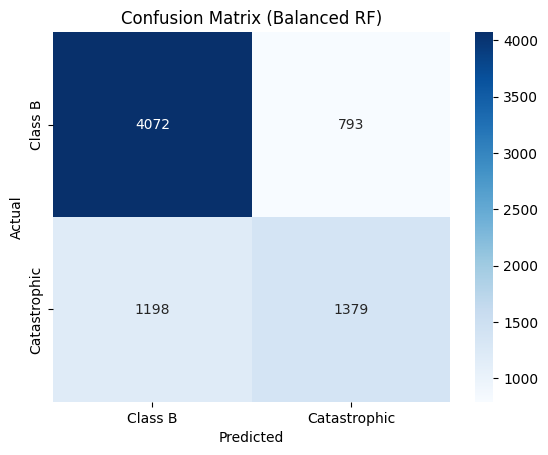

In [30]:
# Use best estimator from RandomizedSearchCV
rf_balanced = random_search.best_estimator_

# Make predictions on the test set
y_pred_balanced = rf_balanced.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))

# 📄 Classification Report
print("\n Classification Report:")
print(classification_report(y_test, y_pred_balanced))

# 🔲 Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_balanced, labels=rf_balanced.classes_)
tick_labels = ["Class B" if label == 0 else "Catastrophic" for label in rf_balanced.classes_]
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=tick_labels,
            yticklabels=tick_labels)
plt.title("Confusion Matrix (Balanced RF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Update the parameter grid with the best parameters fom RandomizedSearchCV - Then perform all the same tests again

In [31]:
# Example: refine around best from RandomizedSearch
best_params = random_search.best_params_

# Optional: use or slightly expand the best found ranges
param_grid = {
    'n_estimators': [best_params['n_estimators'] - 30, best_params['n_estimators'], best_params['n_estimators'] + 30],
    'max_depth': [best_params['max_depth'], 10, 20, 30] if best_params['max_depth'] is not None else [None],
    'max_depth': sorted(set([best_params['max_depth'], 10, 20, 30])),
    'max_features': [best_params['max_features']],
    'min_samples_split': [best_params['min_samples_split'] - 1, best_params['min_samples_split'], best_params['min_samples_split'] + 1],
    'min_samples_leaf': [best_params['min_samples_leaf'] - 1, best_params['min_samples_leaf'], best_params['min_samples_leaf'] + 1]
}


In [32]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42) #add class weighting

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring=scoring
)

In [33]:
grid_search.fit(X_train, y_train)
print("Refined Best Params:", grid_search.best_params_)
#this is the model with the refines best parameters - after having run the random grid CV

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=10, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=90; total time=   5.2s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=90; total time=   5.3s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=90; total time=   5.3s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=90; total time=   5.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=90; total time=   5.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=120; total time=   7.1s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=120; total time=   7.2s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=3, min_samples_split=4, n_estimators=120; to

In [34]:
final_rf = grid_search.best_estimator_

# Best Hyperparameters from Grid Search
print("Best hyperparameters found (from GridSearchCV):")
print(grid_search.best_params_)

# 🌲 Check average tree depth from final model
depths = [estimator.tree_.max_depth for estimator in final_rf.estimators_]
print("Average Tree Depth:", sum(depths) / len(depths))

Best hyperparameters found (from GridSearchCV):
{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 4, 'n_estimators': 150}
Average Tree Depth: 10.0


Accuracy on Test Set: 0.7320612738511153

 Classification Report (Catastrophic = 1):
                  precision    recall  f1-score   support

       Other (0)       0.77      0.84      0.80      4865
Catastrophic (1)       0.63      0.54      0.58      2577

        accuracy                           0.73      7442
       macro avg       0.70      0.69      0.69      7442
    weighted avg       0.72      0.73      0.73      7442



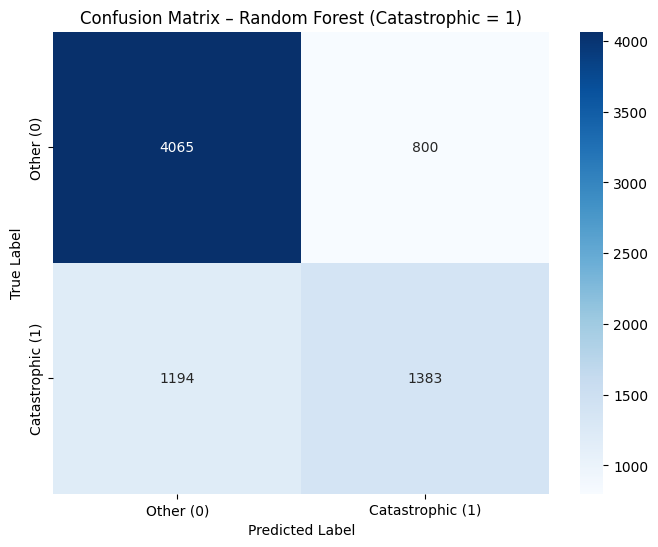

In [35]:


# Predictions
y_pred = final_rf.predict(X_test)

# Accuracy on Test Set
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))

# 📊 Classification Report
print("\n Classification Report (Catastrophic = 1):")
print(classification_report(y_test, y_pred, target_names=["Other (0)", "Catastrophic (1)"]))

# 🔲 Confusion Matrix
class_names = ['Other (0)', 'Catastrophic (1)']  # Match your actual class encoding

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])

# Plot with labels
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix – Random Forest (Catastrophic = 1)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



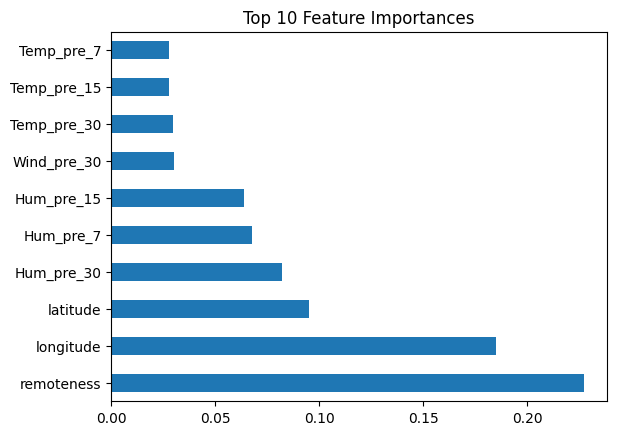

In [36]:
# Feature Importance
feature_importances = pd.Series(final_rf.feature_importances_, index=X_train.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

In [37]:
# Rebuild RF using the best parameters from final GridSearchCV
rf_oob = RandomForestClassifier(
    n_estimators=final_rf.n_estimators,
    max_depth=final_rf.max_depth,
    max_features=final_rf.max_features,
    min_samples_split=final_rf.min_samples_split,
    min_samples_leaf=final_rf.min_samples_leaf,
    bootstrap=True,
    oob_score=True,
    random_state=42
)

rf_oob.fit(X_train, y_train)

# OOB Score (Out-of-Bag estimate of training accuracy)
print("OOB Score (Training Accuracy Est.):", rf_oob.oob_score_)


OOB Score (Training Accuracy Est.): 0.7502855607068467


In [38]:
# Resample (80% of training data) to test model sensitivity to less data
X_small, y_small = resample(X_train, y_train, n_samples=int(0.8 * len(X_train)), random_state=42)

# Rebuild RF with best hyperparameters from final model
rf_small = RandomForestClassifier(**final_rf.get_params())
rf_small.fit(X_small, y_small)

# Accuracy with reduced training set
print("Accuracy with reduced training set:", accuracy_score(y_test, rf_small.predict(X_test)))

# Cross-validation on full training set
cv_scores = cross_val_score(final_rf, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Accuracy with reduced training set: 0.7246707874227358
Cross-Validation Accuracy Scores: [0.72673833 0.73156392 0.72585251 0.72434067 0.72719637]
Mean CV Accuracy: 0.7271383592028497


# Logistic regression

In [44]:
scoring = make_scorer(recall_score, pos_label=1)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        solver='saga',
        penalty='l2',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

param_grid_log = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['liblinear', 'saga'],  # must support l1/l2
    'logreg__max_iter': [500, 1000]
}

grid_search_log = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_log,
    cv=5,
    scoring=scoring,
    verbose=2,
    n_jobs=-1
)

grid_search_log.fit(X_train, y_train)
print("Best parameters:", grid_search_log.best_params_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END logreg__C=0.001, logreg__max_iter=500, logreg__penalty=l1, logreg__solver=liblinear; total time=   0.2s
[CV] END logreg__C=0.001, logreg__max_iter=500, logreg__penalty=l1, logreg__solver=liblinear; total time=   0.2s
[CV] END logreg__C=0.001, logreg__max_iter=500, logreg__penalty=l1, logreg__solver=liblinear; total time=   0.2s
[CV] END logreg__C=0.001, logreg__max_iter=500, logreg__penalty=l1, logreg__solver=liblinear; total time=   0.2s
[CV] END logreg__C=0.001, logreg__max_iter=500, logreg__penalty=l2, logreg__solver=liblinear; total time=   0.2s
[CV] END logreg__C=0.001, logreg__max_iter=500, logreg__penalty=l2, logreg__solver=liblinear; total time=   0.2s
[CV] END logreg__C=0.001, logreg__max_iter=500, logreg__penalty=l1, logreg__solver=liblinear; total time=   0.2s
[CV] END logreg__C=0.001, logreg__max_iter=500, logreg__penalty=l2, logreg__solver=liblinear; total time=   0.1s
[CV] END logreg__C=0.001, logreg__

Accuracy on Test Set: 0.6580220370868046

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.72      0.73      4865
           1       0.51      0.54      0.52      2577

    accuracy                           0.66      7442
   macro avg       0.63      0.63      0.63      7442
weighted avg       0.66      0.66      0.66      7442



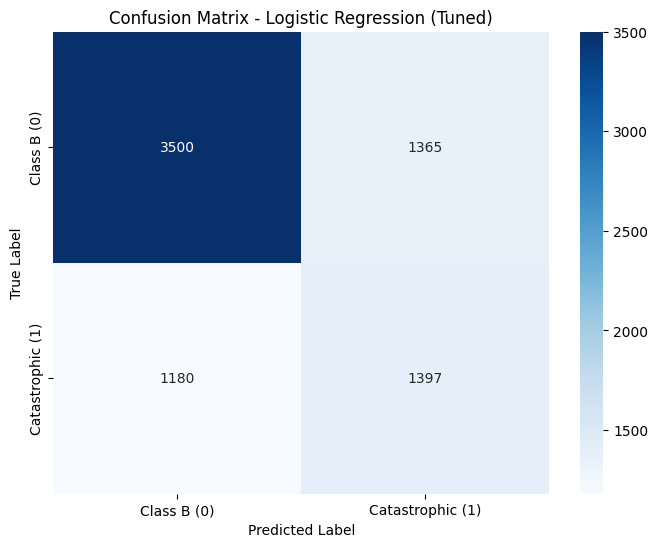


Coefficients (for class = 1 decision boundary):
                      0
latitude       0.000000
longitude     -0.360979
Temp_pre_30    0.000000
Temp_pre_15    0.000000
Temp_pre_7     0.000000
Wind_pre_30    0.000000
Wind_pre_15    0.000000
Wind_pre_7     0.000000
Hum_pre_30    -0.006413
Hum_pre_15    -0.095700
Hum_pre_7     -0.019951
Prec_pre_30    0.000000
Prec_pre_15    0.000000
Prec_pre_7     0.000000
remoteness     0.000000
month_sin      0.000000
month_cos      0.000000
Vegetation_0   0.000000
Vegetation_4   0.000000
Vegetation_9   0.000000
Vegetation_12  0.000000
Vegetation_14  0.000000
Vegetation_15  0.000000
Vegetation_16  0.000000
Best Cross-Validated Recall (Class 0 - Catastrophic Fires): 0.5311014070839398


In [45]:
# Assume you've already done the GridSearchCV like this earlier:

# Reuse best model
best_logreg = grid_search_log.best_estimator_

# Scale the test set using the same scaler from the pipeline
X_test_scaled = best_logreg.named_steps['scaler'].transform(X_test)

# Predict using best model
y_pred_log2 = best_logreg.predict(X_test)

# Evaluation
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred_log2))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log2))

# Confusion Matrix (Logistic Regression - Tuned)
conf_matrix_log2 = confusion_matrix(
    y_test, y_pred_log2,
    labels=best_logreg.named_steps['logreg'].classes_
)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_log2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class B (0)','Catastrophic (1)'],
            yticklabels=['Class B (0)','Catastrophic (1)'])
plt.title("Confusion Matrix - Logistic Regression (Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# Coefficients for Binary Logistic Regression
coef_df = pd.DataFrame(
    best_logreg.named_steps['logreg'].coef_,
    columns=X_train.columns  # No index here!
)

print("\nCoefficients (for class = 1 decision boundary):")
print(coef_df.T)

# Best CV Score (based on Recall for Class 0)
print("Best Cross-Validated Recall (Class 0 - Catastrophic Fires):", grid_search_log.best_score_)


# Comparison - Run everything again

In [46]:
# Predictions
y_pred_rf = final_rf.predict(X_test)
y_pred_log = best_logreg.predict(X_test) #use logreg after GridSearchCV for best hyperparameters

# Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_log = accuracy_score(y_test, y_pred_log)

# Macro F1
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
f1_log = f1_score(y_test, y_pred_log, average='macro')

# Summary table
summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Macro'],
    'Logistic Regression': [acc_log, f1_log],
    'Random Forest': [acc_rf, f1_rf]
})

print("Model Performance Comparison:")
display(summary_df)


Model Performance Comparison:


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.658022,0.732061
1,F1 Macro,0.628344,0.692067


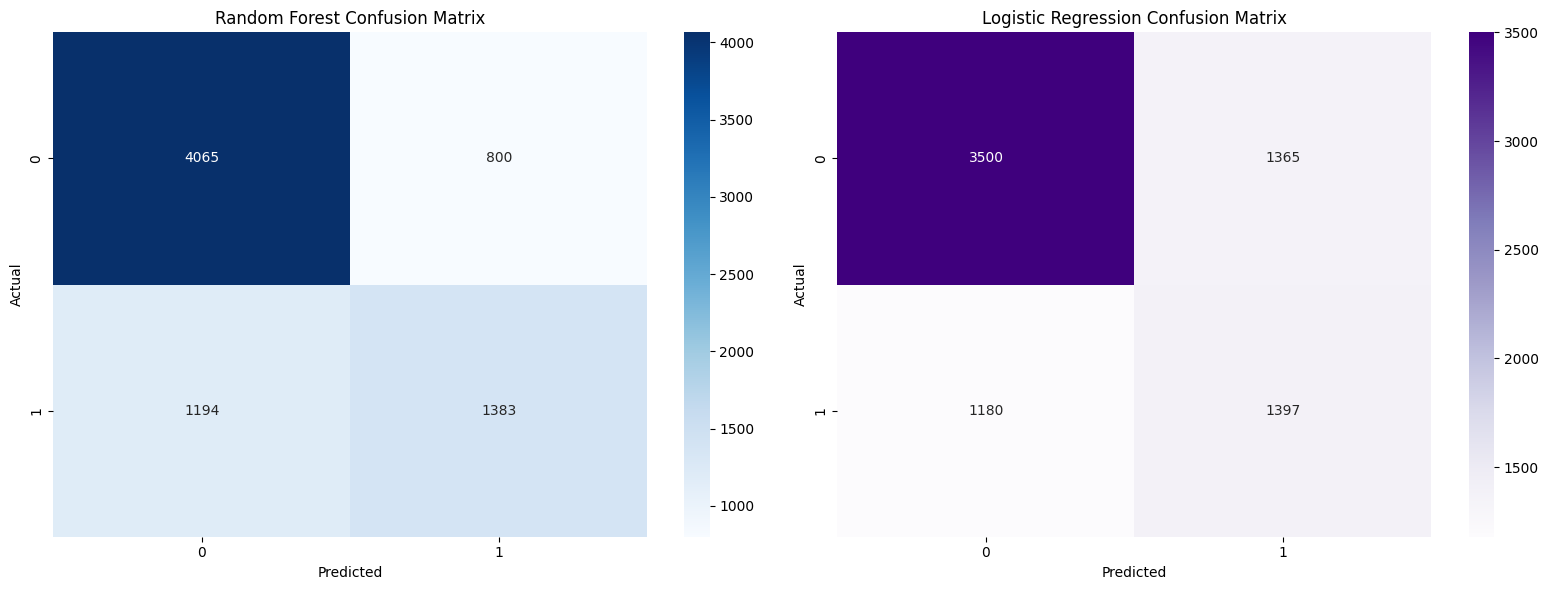

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=final_rf.classes_, yticklabels=final_rf.classes_, ax=axes[0])
axes[0].set_title("Random Forest Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Logistic Regression Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Purples',
            xticklabels=best_logreg.classes_, yticklabels=best_logreg.classes_, ax=axes[1])
axes[1].set_title("Logistic Regression Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


### Exporting the Models

In [52]:
models_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "models"))

joblib.dump(final_rf, os.path.join(models_dir, "random_forest_model.joblib"))
joblib.dump(best_logreg, os.path.join(models_dir, "logistic_regression_model.joblib"))

['/Users/leonkriesmair/Repos/BigDataProject/models/logistic_regression_model.joblib']